In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
import calendar



input_folder = "SP500_Top25_resultados"
name = "Amazon"
ticker = "AMZN"

df_final = pd.read_parquet(f"{input_folder}/{name}_{ticker}_final.parquet")
display(df_final)


df_total_backtest_ordenado = pd.read_parquet(f"{input_folder}/total_backtest_ordenado.parquet")
display(df_total_backtest_ordenado)






,md_inicio,md_fin,probabilidad_positivo,sharpe,sortino,rend_inicio_a_fin,duracion,test_2024,rend_2024,test_2025,rend_2025,media_validacion,anios_positivos,pct_acierto,std_validacion,ranking
49,04-07,04-27,0.80,0.5018,1.1916,9.91,20,NO,NaN,SI,17.35,17.35,1,50.0,NaN,1.0
155,10-27,11-06,0.72,2.3777,2.4440,16.24,10,NO,NaN,SI,9.44,9.44,1,50.0,NaN,2.0
135,08-30,09-17,0.76,2.7359,3.5110,22.27,18,SI,8.14,NO,NaN,8.14,1,50.0,NaN,3.0
63,04-21,04-30,0.76,1.5293,2.6864,14.88,9,NO,NaN,SI,7.41,7.41,1,50.0,NaN,4.0
85,05-27,06-11,0.76,3.5450,5.4333,20.49,15,NO,NaN,SI,7.05,7.05,1,50.0,NaN,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,11-02,11-04,0.80,3.8827,3.3252,7.61,2,NO,NaN,NO,NaN,NaN,0,0.0,NaN,NaN
164,11-09,11-27,0.76,1.3059,4.2993,20.92,18,NO,NaN,NO,NaN,NaN,0,0.0,NaN,NaN
171,11-16,11-30,0.76,0.5334,1.0286,4.39,14,NO,NaN,NO,NaN,NaN,0,0.0,NaN,NaN
178,11-23,11-26,0.88,0.3040,2.0920,1.14,3,NO,NaN,NO,NaN,NaN,0,0.0,NaN,NaN


,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion,name,periodo
66,10000.0,9564.3,-435.7,-4.36,170.0,-175.1,102.1,AbbVie,2024
67,10000.0,10940.2,940.2,9.40,177.0,-156.0,127.4,AbbVie,2025
68,10000.0,10504.5,504.5,5.05,347.0,-175.1,127.4,AbbVie,completo
15,10000.0,11845.9,1845.9,18.46,165.0,-102.5,151.9,Alphabet Class A,2024
16,10000.0,15161.0,5161.0,51.61,179.0,-162.5,194.4,Alphabet Class A,2025
...,...,...,...,...,...,...,...,...,...
40,10000.0,10482.7,482.7,4.83,155.0,-134.9,107.5,Visa,2025
41,10000.0,11826.5,1826.5,18.26,300.0,-134.9,107.5,Visa,completo
72,10000.0,11457.9,1457.9,14.58,92.0,-27.4,87.7,Walmart,2024
73,10000.0,10176.6,176.6,1.77,98.0,-115.1,159.2,Walmart,2025


# 1.- Introducción visual: Heatmap + ranking.

,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion,name,periodo
9,10000.0,10432.5,432.5,4.32,111.0,-81.2,81.4,Amazon,2024
10,10000.0,9909.7,-90.3,-0.90,126.0,-154.6,173.5,Amazon,2025
11,10000.0,10342.2,342.2,3.42,237.0,-154.6,173.5,Amazon,completo


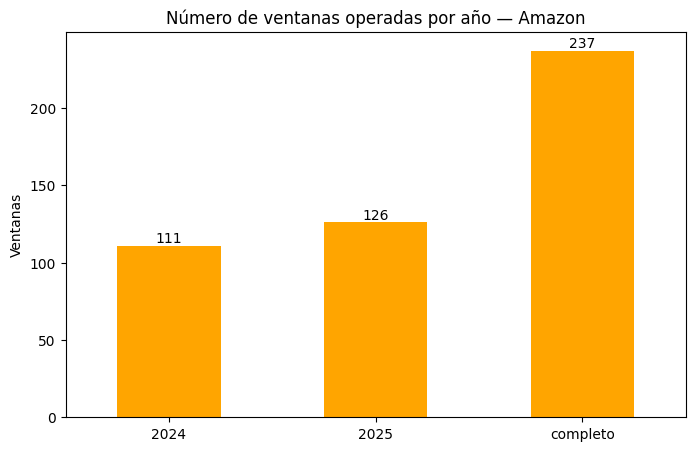

In [ ]:
# Ventanas operadas por año
resumen_anual = df_total_backtest_ordenado[df_total_backtest_ordenado["name"] == name]
display(resumen_anual)


resumen_anual = df_total_backtest_ordenado[df_total_backtest_ordenado["name"] == name].copy()

ax = resumen_anual["ventanas_operadas"].plot(kind="bar", figsize=(8,5), color="orange")

ax.set_xticks(range(len(resumen_anual)))
ax.set_xticklabels(resumen_anual["periodo"], rotation=0)

plt.title(f"Número de ventanas operadas por año — {name}")
plt.ylabel("Ventanas")
plt.xlabel("")

for i, v in enumerate(resumen_anual["ventanas_operadas"]):
    ax.text(
        i,
        v + (v * 0.001),
        f"{v:.0f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()



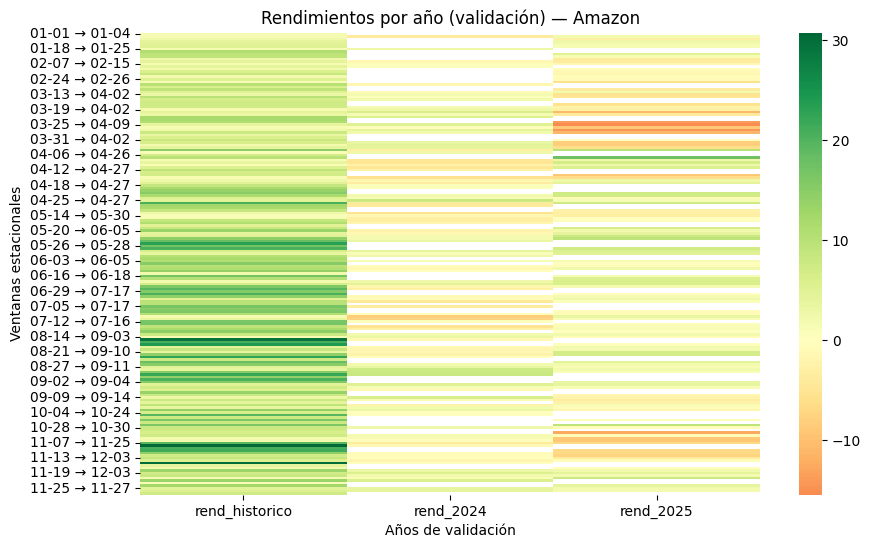

In [6]:
# 1. Preparar el DataFrame para el heatmap
df_plot = df_final.copy()
df_plot = df_plot.rename(columns={"rend_inicio_a_fin": "rend_historico"})
df_plot = df_plot.sort_values("md_inicio")

# 2. Identificar columnas de rendimiento (todas las que empiezan por "rend_")
cols_rend = [c for c in df_plot.columns if c.startswith("rend_")]

# 3. Crear índice tipo "MM-DD → MM-DD"
df_plot.index = df_plot["md_inicio"] + " → " + df_plot["md_fin"]

# 4. Dibujar el heatmap
plt.figure(figsize=(10, 6))
# sns.heatmap(df_plot[cols_rend], annot=False, cmap="RdYlGn", center=0, vmin=-20, vmax=20)
sns.heatmap(df_plot[cols_rend], annot=False, cmap="RdYlGn", center=0, vmin=df_plot[cols_rend].min().min(), vmax=df_plot[cols_rend].max().max())
plt.title(f"Rendimientos por año (validación) — {name}")
plt.xlabel("Años de validación")
plt.ylabel("Ventanas estacionales")
plt.show()


In [9]:


# Copia para no modificar df_final original
df_plot = df_final.copy()
df_plot = df_plot.rename(columns={"rend_inicio_a_fin": "rend_historico"})

# Identificar columnas de validación
cols_rend = [c for c in df_plot.columns if c.startswith("rend_")]

# Preparar DataFrame largo (melt)
df_melt = df_plot.melt(
    id_vars=["md_inicio", "md_fin", "rend_historico"],
    value_vars=cols_rend,
    var_name="año",
    value_name="rendimiento"
)

# Crear etiqueta de ventana
df_melt["ventana"] = df_melt["md_inicio"] + " → " + df_melt["md_fin"]

# Extraer mes para detectar cambios
df_melt["mes"] = df_melt["md_inicio"].str.slice(0, 2).astype(int)

# Ordenar por fecha para que las líneas verticales tengan sentido
df_melt = df_melt.sort_values(["mes", "md_inicio"])

# Detectar posiciones donde cambia el mes
line_positions = []
ventanas_ordenadas = df_melt["ventana"].unique()

meses = df_melt.drop_duplicates("ventana")["mes"].tolist()
for i in range(1, len(meses)):
    if meses[i] != meses[i-1]:
        line_positions.append(i)

# Crear figura
fig = go.Figure()

# --- Línea del rendimiento histórico ---
df_hist = df_melt.drop_duplicates("ventana")

fig.add_trace(
    go.Scatter(
        x=df_hist["ventana"],
        y=df_hist["rend_historico"],
        mode="lines",
        name="Histórico",
        line=dict(color="black", width=3)
    )
)

# --- Puntos de cada año de validación ---
colores = {
    "rend_historico": "black",
    "rend_2024": "#9467bd",
    "rend_2025": "#2ca02c"
}


for año in df_melt["año"].unique():
    df_year = df_melt[df_melt["año"] == año]
    fig.add_trace(
        go.Scatter(
            x=df_year["ventana"],
            y=df_year["rendimiento"],
            mode="markers",
            name=año,
            marker=dict(size=9, color=colores[año], opacity=0.7)
        )
    )

# --- Líneas verticales por meses ---
for pos in line_positions:
    fig.add_vline(
        x=pos,
        line_width=1,
        line_dash="dash",
        line_color="blue"
    )

# Layout
fig.update_layout(
    title=f"Comparativa: Rendimiento histórico vs. validación — {name}",
    xaxis_title="Ventana estacional",
    yaxis_title="Rendimiento (%)",
    height=600,
    width=1400,
)

fig.update_xaxes(tickangle=90)

fig.show()


¿Qué muestra el gráfico de arriba?

La línea negra = rendimiento histórico medio del patrón.

Los puntos de colores = rendimiento real en cada año de validación.

Si los puntos están cerca de la línea → pauta estable.

Si los puntos están muy dispersos → pauta inestable.

Si los puntos están por encima de la línea → pauta mejor de lo esperado.

Si están por debajo → pauta peor de lo esperado.

Es una forma muy potente de evaluar la robustez de cada ventana estacional.

In [ ]:

# --- Preparar datos ---

# Orden 1: ranking puro (mejor → peor)
df_rank = df_final.sort_values("media_validacion", ascending=False)

# Orden 2: orden estacional por fecha de inicio
df_fecha = df_final.sort_values("md_inicio")

# Etiquetas tipo "MM-DD → MM-DD"
df_rank["ventana"] = df_rank["md_inicio"] + " → " + df_rank["md_fin"]
df_fecha["ventana"] = df_fecha["md_inicio"] + " → " + df_fecha["md_fin"]

# --- Detectar cambios de mes para líneas verticales ---
# Extraer mes como número
df_fecha["mes"] = df_fecha["md_inicio"].str.slice(0, 2).astype(int)

# Posiciones donde cambia el mes
line_positions = []
for i in range(1, len(df_fecha)):
    if df_fecha["mes"].iloc[i] != df_fecha["mes"].iloc[i-1]:
        line_positions.append(i)

# --- Crear figura con 2 subplots ---
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.15,
    subplot_titles=(
        "Ranking por media de validación (mejor → peor)",
        "Ranking por fecha de inicio (orden estacional)"
    )
)

# --- Subplot 1: Ranking puro ---
colors_rank = ["green" if v > 0 else "red" for v in df_rank["media_validacion"]]  # <-----------------------

fig.add_trace(
    go.Bar(
        x=df_rank["ventana"],
        y=df_rank["media_validacion"],
        marker_color=colors_rank,
        name="Ranking puro"
    ),
    row=1, col=1
)

# --- Subplot 2: Orden por fecha ---
colors_fecha = ["green" if v > 0 else "red" for v in df_fecha["media_validacion"]]  # <-----------------------

fig.add_trace(
    go.Bar(
        x=df_fecha["ventana"],
        y=df_fecha["media_validacion"],
        marker_color=colors_fecha,
        name="Orden estacional"
    ),
    row=2, col=1
)

# --- Añadir líneas verticales por meses en el subplot 2 ---
for pos in line_positions:
    fig.add_vline(
        x=pos,
        line_width=1,
        line_dash="dash",
        line_color="blue",
        row=2, col=1
    )

# --- Layout ---
fig.update_layout(
    height=900,
    width=1200,
    title_text=f"Comparativa de Rankings de Ventanas Estacionales — {name}",
    showlegend=False
)

fig.update_xaxes(tickangle=90)

fig.show()


# 2.- Robustez: Boxplot + porcentaje de acierto + scatter media vs volatilidad.

In [11]:
# Transformar de formato ancho a largo
df_plot = df_final.copy()
df_plot = df_plot.rename(columns={"rend_inicio_a_fin": "rend_historico"})
df_plot = df_plot.sort_values("md_inicio")

df_box = df_plot[cols_rend].melt(
    var_name="Año",
    value_name="Rendimiento"
)

# Crear boxplot interactivo
fig = px.box(
    df_box,
    x="Año",
    y="Rendimiento",
    title=f"Distribución de rendimientos por año — {name}",
    points="all",  # muestra todos los puntos individuales
    template="plotly_white",
    color="Año"
)

fig.update_traces(marker=dict(size=4, opacity=0.6))

# Quitar etiqueta del eje X
fig.update_xaxes(title_text=None)
# Quitar leyenda
fig.update_layout(showlegend=False)

fig.show()



In [13]:
# --- Preparar datos ---

df_pct = df_final.sort_values("md_inicio").copy()

# Etiqueta de ventana
df_pct["ventana"] = df_pct["md_inicio"] + " → " + df_pct["md_fin"]

# Extraer mes para detectar cambios
df_pct["mes"] = df_pct["md_inicio"].str.slice(0, 2).astype(int)

# Detectar posiciones donde cambia el mes
line_positions = []
meses = df_pct["mes"].tolist()
for i in range(1, len(meses)):
    if meses[i] != meses[i-1]:
        line_positions.append(i)

# --- Colorear por cuartiles ---
q1, q2, q3 = np.percentile(df_pct["pct_acierto"], [25, 50, 75])

def asignar_cuartil(valor):
    if valor <= q1:
        return "Q1 (bajo)"
    elif valor <= q2:
        return "Q2"
    elif valor <= q3:
        return "Q3"
    else:
        return "Q4 (alto)"

df_pct["cuartil"] = df_pct["pct_acierto"].apply(asignar_cuartil)

# Paleta de colores por cuartil
colores = {
    "Q1 (bajo)": "#003f5c",
    "Q2": "#59defc",
    "Q3": "#91bfdb",
    "Q4 (alto)": "#76ff03"
}

# --- Crear figura ---
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=df_pct["ventana"],
        y=df_pct["pct_acierto"],
        marker_color=[colores[c] for c in df_pct["cuartil"]],
        text=df_pct["cuartil"],
        hovertemplate="<b>%{x}</b><br>% acierto: %{y:.1f}%<br>Cuartil: %{text}<extra></extra>"
    )
)

# --- Líneas verticales por meses ---
for pos in line_positions:
    fig.add_vline(
        x=pos - 0.5,
        line_width=1,
        line_dash="dash",
        line_color="gray"
    )

# --- Línea horizontal de referencia ---
fig.add_hline(
    y=50,
    line_width=2,
    line_dash="dot",
    line_color="black",
    annotation_text="50% referencia",
    annotation_position="top left"
)

# --- Layout ---
fig.update_layout(
    title=f"Porcentaje aciertos por ventana — {name}",
    xaxis_title="Ventana estacional",
    yaxis_title="% acierto",
    height=600,
    width=1400,
    xaxis_tickangle=90,
    showlegend=False
)

fig.show();



In [17]:
# Calcular el máximo ranking
max_rank = int(df_final["ranking"].max())

fig = px.scatter(
    df_final,
    x="media_validacion",
    y="std_validacion",
    title=f"Rendimiento medio vs. Volatilidad de ventanas estacionales - {name}",
    labels={
        "media_validacion": "Rendimiento medio (%)",
        "std_validacion": "Volatilidad (std)"
    },
    hover_data=["md_inicio", "md_fin", "ranking"],
    color="ranking",
    color_continuous_scale="viridis",
    range_color=[1, max_rank]
)

fig.update_traces(marker=dict(size=10, opacity=0.8))

fig.update_layout(
    height=600,
    width=900,
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True),
    coloraxis_colorbar=dict(
        title=dict(
            text="Ranking ventanas",
            side="right"
        ),
        tickvals=[1, max_rank],
        ticktext=[f"1 (mejor)", f"{max_rank} (peor)"],
        x=1.15,      # mueve la barra hacia la derecha
        xpad=30      # añade espacio entre barra y título
    )
)
fig.update_traces(marker=dict(size=10, opacity=0.6))


fig.show()



In [18]:
# --- Detectar columna de volatilidad automáticamente ---
col_std = [c for c in df_final.columns if "std" in c.lower()][0]

# --- Copia del DF ---
df_scatter = df_final.copy()

# --- LIMPIEZA CRÍTICA: eliminar inf, -inf y NaN ---
df_scatter = df_scatter.replace([np.inf, -np.inf], np.nan)
df_scatter = df_scatter.dropna(subset=["media_validacion", col_std])

# --- Resetear índice para evitar desalineaciones ---
df_scatter = df_scatter.reset_index(drop=True)

# --- Preparar datos para clustering ---
df_cluster = df_scatter[["media_validacion", col_std]]

# Si hay menos de 3 puntos válidos, no se puede hacer clustering
if len(df_cluster) >= 3:
    kmeans = KMeans(n_clusters=3, random_state=0)
    clusters = kmeans.fit_predict(df_cluster)
    df_scatter["cluster"] = clusters
else:
    df_scatter["cluster"] = 0  # un solo cluster si no hay suficientes puntos

# Paleta de colores para clusters
palette = px.colors.qualitative.Set2

# --- Crear figura ---
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_scatter["media_validacion"],
        y=df_scatter[col_std],
        mode="markers",
        marker=dict(
            size=12,
            opacity=0.8,
            color=[palette[int(c)] for c in df_scatter["cluster"]],
            line=dict(width=1, color="black")
        ),
        text=df_scatter["md_inicio"] + " → " + df_scatter["md_fin"],
        hovertemplate="<b>%{text}</b><br>Media: %{x:.2f}%<br>Volatilidad: %{y:.2f}<extra></extra>"
    )
)

# --- Líneas de referencia ---
fig.add_hline(
    y=df_scatter[col_std].median(),
    line_dash="dot",
    line_color="gray",
    annotation_text="Mediana volatilidad",
    annotation_position="top right",
    annotation_yshift=5
)

fig.add_vline(
    x=df_scatter["media_validacion"].median(),
    line_dash="dot",
    line_color="gray",
    annotation_text="Mediana rend. medio",
    # annotation_text="Mediana media",
    annotation_position="top left",
    annotation_yshift=20,
    annotation_xshift=60
)

# --- Anotaciones ---
best_idx = df_scatter["media_validacion"].idxmax()
fig.add_annotation(
    x=df_scatter.loc[best_idx, "media_validacion"],
    y=df_scatter.loc[best_idx, col_std],
    text="⭐ Mejor Rendimiento",
    showarrow=True,
    arrowhead=2,
    font=dict(color="red", size=16),
    arrowcolor="red"
)

stable_idx = df_scatter[col_std].idxmin()
fig.add_annotation(
    x=df_scatter.loc[stable_idx, "media_validacion"],
    y=df_scatter.loc[stable_idx, col_std],
    text="🔒 Más estable",
    showarrow=True,
    arrowhead=2,
    font=dict(color="red", size=16),
    arrowcolor="red"
)

# --- Layout ---
fig.update_layout(
    title=f"Rend. medio vs. Volatilidad de ventanas estacionales (3 clusters) — {name}",
    xaxis_title="Rendimiento medio (%)",
    yaxis_title="Volatilidad (std)",
    height=700,
    width=900,
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True),
)

fig.show()
# st.plotly_chart(fig, width="stretch")


Alta Rend. medio + baja volatilidad: ventanas ideales, consistentes y rentables.

Alta Rend. medio + alta volatilidad: ventanas potentes pero arriesgadas.

Baja Rend. medio + baja volatilidad: ventanas estables pero poco útiles.

Baja Rend. medio + alta volatilidad: ventanas débiles e impredecibles.

# 3.- Resultados monetarios: Beneficio anual + mejor/peor operación + capital final.

In [19]:

display(df_total_backtest_ordenado)
df_filtrado = df_total_backtest_ordenado[df_total_backtest_ordenado["name"] == name][["capital_inicial", 
                                                                                    "capital_final",
                                                                                    "beneficio_total",
                                                                                    "retorno_%",
                                                                                    "ventanas_operadas",
                                                                                    "drawdown_max",
                                                                                    "mejor_operacion",
                                                                                    "periodo"
                                                                                    ]]
display(df_filtrado)

df2 = (
    df_filtrado.set_index("periodo")          # periodo pasa a ser índice
    # .T                              # transponemos filas ↔ columnas
)
display(df2)

,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion,name,periodo
66,10000.0,9564.3,-435.7,-4.36,170.0,-175.1,102.1,AbbVie,2024
67,10000.0,10940.2,940.2,9.40,177.0,-156.0,127.4,AbbVie,2025
68,10000.0,10504.5,504.5,5.05,347.0,-175.1,127.4,AbbVie,completo
15,10000.0,11845.9,1845.9,18.46,165.0,-102.5,151.9,Alphabet Class A,2024
16,10000.0,15161.0,5161.0,51.61,179.0,-162.5,194.4,Alphabet Class A,2025
...,...,...,...,...,...,...,...,...,...
40,10000.0,10482.7,482.7,4.83,155.0,-134.9,107.5,Visa,2025
41,10000.0,11826.5,1826.5,18.26,300.0,-134.9,107.5,Visa,completo
72,10000.0,11457.9,1457.9,14.58,92.0,-27.4,87.7,Walmart,2024
73,10000.0,10176.6,176.6,1.77,98.0,-115.1,159.2,Walmart,2025


,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion,periodo
9,10000.0,10432.5,432.5,4.32,111.0,-81.2,81.4,2024
10,10000.0,9909.7,-90.3,-0.90,126.0,-154.6,173.5,2025
11,10000.0,10342.2,342.2,3.42,237.0,-154.6,173.5,completo


,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion
periodo,,,,,,,
2024,10000.0,10432.5,432.5,4.32,111.0,-81.2,81.4
2025,10000.0,9909.7,-90.3,-0.90,126.0,-154.6,173.5
completo,10000.0,10342.2,342.2,3.42,237.0,-154.6,173.5


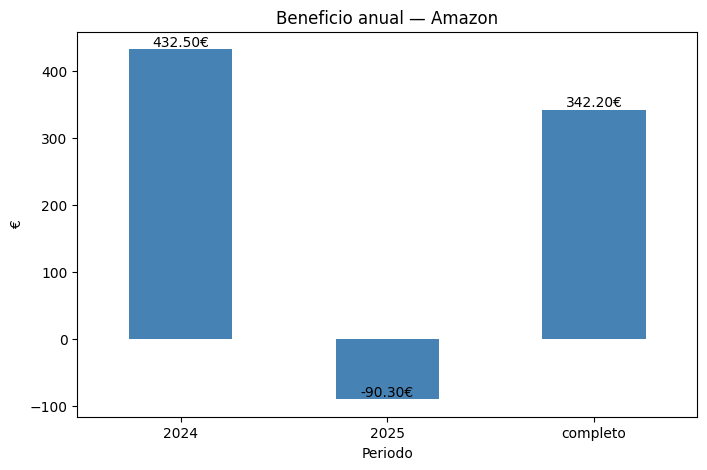

In [20]:
# Beneficio total por año
resumen_anual = df2

ax = resumen_anual["beneficio_total"].plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title(f"Beneficio anual — {name}")
plt.ylabel("€")
plt.xlabel("Periodo")

# Poner etiquetas del eje X en horizontal
plt.xticks(rotation=0)

# Añadir el valor encima de cada barra 
for i, v in enumerate(resumen_anual["beneficio_total"]): 
    ax.text( 
            i, 
            v + (v * 0.001), # un pequeño margen por encima de la barra 
            f"{v:.2f}€", 
            ha='center', 
            va='bottom', 
            fontsize=10 
            )

plt.show()


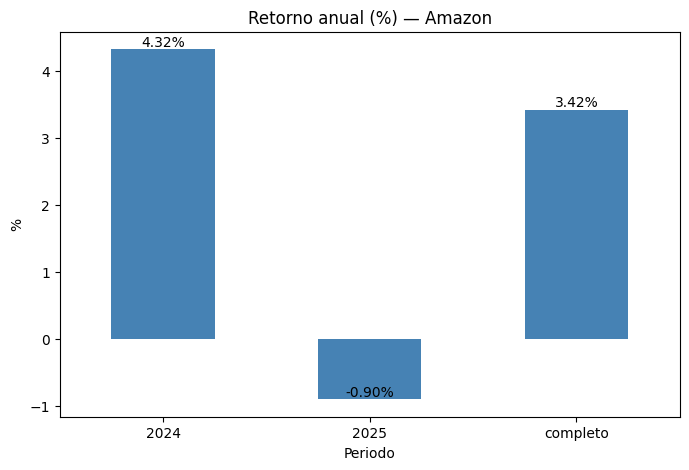

In [21]:
# Retorno anual (%)
ax = resumen_anual["retorno_%"].plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title(f"Retorno anual (%) — {name}")
plt.ylabel("%")
plt.xlabel("Periodo")

# Poner etiquetas del eje X en horizontal
plt.xticks(rotation=0)

# Añadir el valor encima de cada barra 
for i, v in enumerate(resumen_anual["retorno_%"]): 
    ax.text( 
            i, 
            v + (v * 0.001), # un pequeño margen por encima de la barra 
            f"{v:.2f}%", 
            ha='center', 
            va='bottom', 
            fontsize=10 
            )

plt.show()



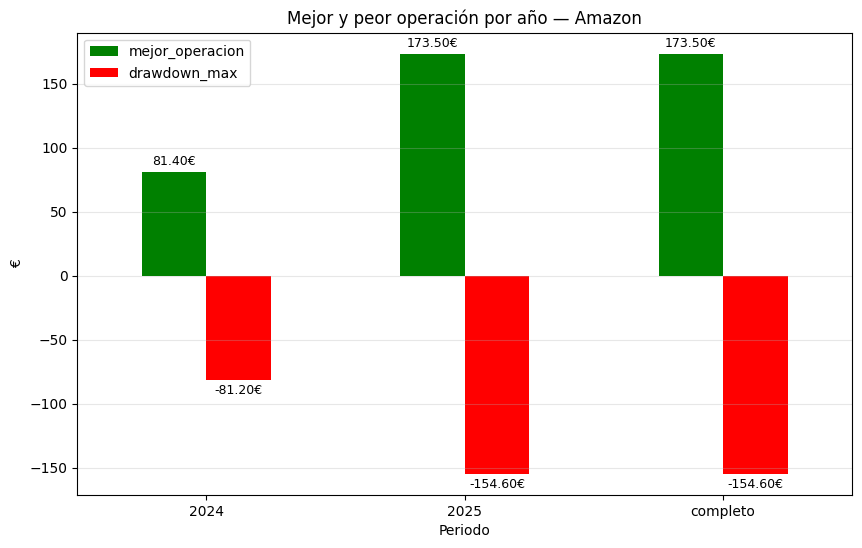

In [22]:
# Gráfico combinado: mejor vs peor operación

ax = resumen_anual[["mejor_operacion", "drawdown_max"]].plot(
    kind="bar",
    figsize=(10,6),
    color=["green", "red"]
)

plt.title(f"Mejor y peor operación por año — {name}")
plt.ylabel("€")
plt.xlabel("Periodo")
plt.grid(axis="y", alpha=0.3)
# Poner etiquetas del eje X en horizontal
plt.xticks(rotation=0)

# Añadir etiquetas a cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f€",
        padding=3,
        fontsize=9
    )

plt.show()


# 4.- Análisis avanzado: Histograma + correlación + curva de equity.

In [23]:
# HISTOGRAMA

rendimientos = pd.concat([
    df_final["rend_2024"],
    df_final["rend_2025"]
], axis=0)

fig = px.histogram(
    rendimientos,
    nbins=40,
    marginal="box",
    opacity=0.75,
    title=f"Histograma de rendimientos por ventana — {name}",
    labels={"value": "Rendimiento (%)"},
    template="plotly_white"
)

fig.update_traces(marker_color="steelblue")

# Quitar la leyenda "variable"
fig.update_layout(showlegend=False)
fig.show()


In [24]:
# Crear un DataFrame largo con etiqueta de año
rendimientos = pd.DataFrame({
    "valor": pd.concat([df_final["rend_2024"], df_final["rend_2025"]], axis=0),
    "año":   ["2024"] * len(df_final) + ["2025"] * len(df_final)
})

fig = px.histogram(
    rendimientos,
    x="valor",
    color="año",              # colores distintos por año
    nbins=40,
    marginal="box",
    opacity=0.55,             # permite ver la superposición
    barmode="overlay",        # superponer histogramas
    title=f"Histograma de rendimientos por ventana y año — {name}",
    labels={"valor": "Rendimiento (%)"},
    template="plotly_white",
    color_discrete_map={
        "2024": "steelblue",
        "2025": "indianred"
    }
)

fig.show()


In [26]:


# DataFrame largo
rendimientos = pd.DataFrame({
    "valor": pd.concat([df_final["rend_2024"], df_final["rend_2025"]], axis=0),
    "año":   ["2024"] * len(df_final) + ["2025"] * len(df_final)
})

# Crear figura con subplots
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    vertical_spacing=0.05
)

# --- Histograma superpuesto ---
fig.add_trace(
    go.Histogram(
        x=rendimientos["valor"],
        nbinsx=40,
        opacity=0.55,
        marker_color="steelblue",
        name="2024",
        xbins=dict(size=1),
        histnorm=None
    ),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x=rendimientos.loc[rendimientos["año"] == "2025", "valor"],
        nbinsx=40,
        opacity=0.55,
        marker_color="indianred",
        name="2025",
        xbins=dict(size=1),
        histnorm=None
    ),
    row=1, col=1
)

# --- Violin plot combinado ---
fig.add_trace(
    go.Violin(
        x=rendimientos["año"],
        y=rendimientos["valor"],
        box_visible=True,
        meanline_visible=True,
        spanmode="hard",
        line_color="black",
        fillcolor="lightgray",
        opacity=0.7,
        name="Densidad"
    ),
    row=2, col=1
)

# Layout
fig.update_layout(
    title=f"Distribución de rendimientos por ventana — {name}",
    barmode="overlay",
    template="plotly_white",
    height=700
)

fig.update_xaxes(title_text="Rendimiento (%)", row=1, col=1)
fig.update_yaxes(title_text="Densidad", row=1, col=1)
fig.update_yaxes(title_text="Distribución", row=2, col=1)

fig.show()


In [27]:
# MATRIZ CORRELACION ENTRE AÑOS

df_corr = df_final[["rend_2024", "rend_2025"]].corr("pearson").round(3)

# Crear máscara para dejar solo la parte inferior
mask = np.tril(np.ones_like(df_corr, dtype=bool))

# Aplicar máscara
corr_masked = df_corr.where(mask)

fig = px.imshow(
    corr_masked,
    text_auto=True,
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title=f"Matriz de correlación entre años — {name}",
    template="plotly_white"
)

fig.show()


In [30]:
# CURVA EQUITY

# Convertir md_inicio (MM-DD) en fecha artificial
df_final["fecha_md"] = pd.to_datetime("2000-" + df_final["md_inicio"], format="%Y-%m-%d")

# Extraer nombre de mes (para mostrar en el eje X)
df_final["mes_nombre"] = df_final["fecha_md"].dt.strftime("%B")



capital_inicial = 10000
capital_por_ventana = 1000
anios = [2024, 2025]

fig = go.Figure()

for year in anios:
    # Filtrar solo ventanas con datos para ese año
    df_year = df_final[df_final[f"rend_{year}"].notna()].copy()

    # Beneficio por ventana
    df_year["benef"] = (df_year[f"rend_{year}"] / 100) * capital_por_ventana

    # Equity acumulado
    df_year["equity"] = capital_inicial + df_year["benef"].cumsum()

    # Ordenar por fecha MM-DD
    df_year = df_year.sort_values("fecha_md")
    
    color_map = {
        2024: "#1f77b4",   # azul
        2025: "#DAA520"    # naranja
    }

    fig.add_trace(go.Scatter(
        x=df_year["fecha_md"],       # eje X con mes y día
        y=df_year["equity"],
        mode="lines+markers",
        name=f"Equity {year}",
        line=dict(width=3, color=color_map[year]),
        marker=dict(size=6, color=color_map[year]),
        fill="tozeroy",
        opacity=0.25
    ))

# Línea horizontal del capital inicial
fig.add_hline(
    y=capital_inicial,
    line=dict(color="gray", width=2, dash="dash"),
    annotation_text="Capital inicial",
    annotation_position="top left",
    annotation_yshift=-25
)

fig.update_layout(
    title=f"Curva de equity anual — {name}",
    xaxis_title="Mes",
    yaxis_title="Capital (€)",
    template="plotly_white",
    hovermode="x unified",
    xaxis=dict(
        tickformat="%b",  # Mostrar solo el mes (Jan, Feb, Mar…)
        dtick="M1"        # Un tick por mes
    )
)

fig.show()



# 5.- Conclusiones: Ventanas más sólidas, riesgos, oportunidades.

In [40]:


df = df_scatter.copy()

# Umbrales dinámicos
med_media = df["media_validacion"].median()
med_std   = df["std_validacion"].median()
med_sharpe = df["sharpe"].median()
med_sortino = df["sortino"].median()

# Clasificación
def clasificar(fila):
    media = fila["media_validacion"]
    std   = fila["std_validacion"]
    r24   = fila["rend_2024"]
    r25   = fila["rend_2025"]
    prob  = fila["probabilidad_positivo"]
    sharpe = fila["sharpe"]
    sortino = fila["sortino"]

    # Ventanas sólidas
    if media >= med_media and std <= med_std and prob >= 0.70 and sharpe >= med_sharpe:
        return "solida"

    # Ventanas estables
    if std <= med_std and media >= 0:
        return "estable"

    # Ventanas agresivas
    if media >= med_media and std > med_std:
        return "agresiva"

    # Ventanas débiles
    if media < med_media and std > med_std:
        return "debil"

    return "neutral"

df["categoria"] = df.apply(clasificar, axis=1)

# Identificar mejor y más estable
mejor = df.loc[df["media_validacion"].idxmax()]
mas_estable = df.loc[df["std_validacion"].idxmin()]

# display(df)
# df.groupby(["categoria"])[["categoria"]].count()
# df.groupby("categoria").size().reset_index(name="Cantidad")
df.groupby(["categoria"])[["categoria"]].count().rename(columns={"categoria": "Cantidad"})



,Cantidad
categoria,
agresiva,17
debil,25
estable,17
neutral,17
solida,9


In [47]:


orden_categorias = ["solida", "estable", "agresiva", "debil", "neutral"]

# Contar ventanas por categoría
df_counts = (
    df.groupby("categoria")[["categoria"]]
      .count()
      .rename(columns={"categoria": "Cantidad"})
      .reset_index()
      .sort_values("Cantidad", ascending=True)
)

# Orden dinámico según la cantidad (ya ordenado)
orden_categorias_asc = df_counts["categoria"].tolist()

fig = px.pie(
    df_counts,
    names="categoria",
    values="Cantidad",
    hole=0.4,
    title=f"Distribución ventanas por categoría - {name}",
    category_orders={"categoria": orden_categorias_asc},
    color="categoria",
    color_discrete_map={
    "solida": "#4C72B0",     # azul suave
    "estable": "#55A868",    # verde elegante
    "agresiva": "#C44E52",   # rojo frambuesa
    "debil": "#8172B2",      # violeta suave
    "neutral": "#CCB974"     # beige dorado
    },
    hover_data=["Cantidad"]   
)

fig.update_traces(rotation=0)

fig.show()




In [69]:


# ---------------------------------------------------------
# 1) CLASIFICACIÓN NUEVA
# ---------------------------------------------------------

df = df_scatter.copy()

med_media = df["media_validacion"].median()
med_std   = df["std_validacion"].median()
med_sharpe = df["sharpe"].median()
med_sortino = df["sortino"].median()

def clasificar(fila):
    media = fila["media_validacion"]
    std   = fila["std_validacion"]
    prob  = fila["probabilidad_positivo"]
    sharpe = fila["sharpe"]

    if media >= med_media and std <= med_std and prob >= 0.70 and sharpe >= med_sharpe:
        return "solida"

    if std <= med_std and media >= 0:
        return "estable"

    if media >= med_media and std > med_std:
        return "agresiva"

    if media < med_media and std > med_std:
        return "debil"

    return "neutral"

df["categoria"] = df.apply(clasificar, axis=1)

# ---------------------------------------------------------
# 2) FUNCIONES DE FECHA (sin cambios)
# ---------------------------------------------------------

def convertir_fecha_segura(md):
    mes, dia = map(int, md.split("-"))
    ultimo_dia = calendar.monthrange(2000, mes)[1]
    dia = min(dia, ultimo_dia)
    return datetime(2000, mes, dia)

def punto_medio(md_inicio, md_fin):
    f1 = convertir_fecha_segura(md_inicio)
    f2 = convertir_fecha_segura(md_fin)
    return f1 + (f2 - f1) / 2

# ---------------------------------------------------------
# 3) PREPARAR DATOS PARA EL GRÁFICO
# ---------------------------------------------------------

df["fecha_inicio"] = df["md_inicio"].apply(convertir_fecha_segura)
df["fecha_fin"] = df["md_fin"].apply(convertir_fecha_segura)
df["fecha_medio"] = df.apply(lambda r: punto_medio(r["md_inicio"], r["md_fin"]), axis=1)

# Colores modernos
colores_modernos = {
    "solida": "#4C72B0",
    "estable": "#55A868",
    "agresiva": "#C44E52",
    "debil": "#8172B2",
    "neutral": "#CCB974"
}

# ---------------------------------------------------------
# 4) GRÁFICO ESTACIONAL EN PLOTLY (idéntico al original)
# ---------------------------------------------------------

def grafico_estacional_plotly(df):
    fig = go.Figure()

    # Añadir puntos por categoría (como Matplotlib)
    for categoria, color in colores_modernos.items():
        df_cat = df[df["categoria"] == categoria]

        fig.add_trace(go.Scatter(
            x=df_cat["fecha_medio"],
            y=df_cat["rend_inicio_a_fin"],
            mode="markers",
            name=categoria,
            marker=dict(
                size=10,
                color=color,
                line=dict(width=1, color="black")
            ),
            hovertemplate=(
                "<b>%{text}</b><br>" +
                "Rendimiento: %{y:.2f}%<br>" +
                "Inicio: %{customdata[0]}<br>" +
                "Fin: %{customdata[1]}<br>" +
                "<extra></extra>"
            ),
            text=df_cat["categoria"],
            customdata=np.stack((df_cat["md_inicio"], df_cat["md_fin"]), axis=-1)
        ))

    # Eje X con meses en español
    meses_es = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    fig.update_layout(
        title=f"Estacionalidad ventanas por Categoría - {name}",
        xaxis=dict(
            tickmode="array",
            tickvals=[datetime(2000, m, 1) for m in range(1, 13)],
            ticktext=meses_es
        ),
        yaxis_title="Rendimiento (%)",
        xaxis_title="Mes",
        template="simple_white",
        legend_title="Categoría",
        # height=500
        height=600,
        width=1000
    )

    fig.show()

# ---------------------------------------------------------
# 5) LLAMADA AL GRÁFICO
# ---------------------------------------------------------

grafico_estacional_plotly(df)


In [48]:


def clasificar_ventanas(df):
    """
    Clasifica ventanas estacionales en:
    - sólida
    - estable
    - agresiva
    - débil

    Requisitos mínimos del DataFrame:
    columnas = [
        'md_inicio', 'md_fin', 'media_validacion', 'std_validacion',
        'anios_positivos', 'pct_acierto'
    ]
    """

    df = df.copy()

    # Asegurar que no haya NaN en std para comparaciones
    df["std_validacion"] = df["std_validacion"].fillna(np.inf)

    # --- Criterios ---
    solida = (
        (df["media_validacion"] >= 6) &
        (df["std_validacion"] <= 3) &
        (df["anios_positivos"] == 2) &
        (df["pct_acierto"] == 100)
    )

    estable = (
        (df["media_validacion"].between(3, 6)) &
        (df["std_validacion"] <= 4) &
        (df["anios_positivos"] >= 1)
    )

    agresiva = (
        (df["media_validacion"] >= 6) &
        (df["std_validacion"] > 3)
    )

    debil = (
        (df["media_validacion"] < 3) |
        (df["anios_positivos"] == 0) |
        (df["std_validacion"] > 6)
    )

    # --- Asignación de categoría ---
    df["categoria"] = "debil"  # por defecto

    df.loc[agresiva, "categoria"] = "agresiva"
    df.loc[estable, "categoria"] = "estable"
    df.loc[solida, "categoria"] = "solida"

    # Las sólidas deben sobrescribir cualquier otra categoría
    df.loc[solida, "categoria"] = "solida"

    return df


# -------------------------
# EJEMPLO DE USO
# -------------------------

# df_scatter = ...  # tu DataFrame original

df_clasificado = clasificar_ventanas(df_scatter)

print(df_clasificado[["md_inicio", "md_fin", "media_validacion", "std_validacion", "categoria"]])


   md_inicio md_fin  media_validacion  std_validacion categoria
0      05-23  06-11             5.580        5.275017     debil
1      06-26  07-16             5.310        0.947523   estable
2      11-19  12-03             4.900        0.848528   estable
3      05-22  06-11             4.845        4.405275     debil
4      08-28  09-17             4.825        3.882016   estable
..       ...    ...               ...             ...       ...
80     11-06  11-25            -4.750        6.208398     debil
81     03-27  04-09            -5.115       13.017836     debil
82     03-25  04-09            -5.140       14.594684     debil
83     11-07  11-25            -5.370        2.022325     debil
84     04-15  04-22            -5.990        0.551543     debil

[85 rows x 5 columns]


In [49]:

# ============================================================
#   CLASIFICACIÓN GENERAL DE VENTANAS ESTACIONALES
# ============================================================

def clasificar_ventanas(df):
    """
    Clasifica ventanas estacionales en:
    - solida
    - estable
    - agresiva
    - debil

    Requisitos mínimos del DataFrame:
    columnas = [
        'md_inicio', 'md_fin', 'media_validacion', 'std_validacion',
        'anios_positivos', 'pct_acierto'
    ]
    """

    df = df.copy()

    # Reemplazar NaN en std por infinito para evitar falsos positivos
    df["std_validacion"] = df["std_validacion"].fillna(np.inf)

    # -----------------------------
    # Criterios
    # -----------------------------
    solida = (
        (df["media_validacion"] >= 6) &
        (df["std_validacion"] <= 3) &
        (df["anios_positivos"] == 2) &
        (df["pct_acierto"] == 100)
    )

    estable = (
        (df["media_validacion"].between(3, 6)) &
        (df["std_validacion"] <= 4) &
        (df["anios_positivos"] >= 1)
    )

    agresiva = (
        (df["media_validacion"] >= 6) &
        (df["std_validacion"] > 3)
    )

    debil = (
        (df["media_validacion"] < 3) |
        (df["anios_positivos"] == 0) |
        (df["std_validacion"] > 6)
    )

    # -----------------------------
    # Asignación de categoría
    # -----------------------------
    df["categoria"] = "debil"  # por defecto

    df.loc[agresiva, "categoria"] = "agresiva"
    df.loc[estable, "categoria"] = "estable"
    df.loc[solida, "categoria"] = "solida"

    return df


# ============================================================
#   MEJOR VENTANA ABSOLUTA
# ============================================================

def mejor_ventana(df):
    """
    Devuelve la ventana con mayor media_validacion.
    """
    return df.loc[df["media_validacion"].idxmax()]


# ============================================================
#   VENTANA MÁS ESTABLE
# ============================================================

def ventana_mas_estable(df):
    """
    Devuelve la ventana con menor std_validacion
    (solo entre ventanas con media_validacion > 0).
    """
    df_pos = df[df["media_validacion"] > 0].copy()
    return df_pos.loc[df_pos["std_validacion"].idxmin()]


# ============================================================
#   RESUMEN ESTACIONAL POR MES
# ============================================================

def resumen_estacional(df):
    """
    Crea un resumen por mes con:
    - media promedio
    - std promedio
    - % de ventanas sólidas
    - % de ventanas débiles
    """

    df = df.copy()

    # Extraer mes de md_inicio
    df["mes"] = df["md_inicio"].str.slice(0, 2).astype(int)

    resumen = df.groupby("mes").agg({
        "media_validacion": "mean",
        "std_validacion": "mean",
        "categoria": lambda x: x.value_counts(normalize=True).to_dict()
    })

    return resumen


# ============================================================
#   FUNCIÓN MAESTRA: TODO EN UNO
# ============================================================

def analizar_ventanas(df):
    """
    Devuelve:
    - df_clasificado
    - mejor ventana
    - ventana más estable
    - resumen estacional
    """

    df_clas = clasificar_ventanas(df)
    best = mejor_ventana(df_clas)
    estable = ventana_mas_estable(df_clas)
    estacional = resumen_estacional(df_clas)

    return df_clas, best, estable, estacional


# ============================================================
#   EJEMPLO DE USO
# ============================================================

# df_scatter = ...  # tu DataFrame original

df_final, mejor, estable, estacional = analizar_ventanas(df_scatter)

print(df_final.head())
print("MEJOR VENTANA:\n", mejor)
print("VENTANA MÁS ESTABLE:\n", estable)
print("RESUMEN ESTACIONAL:\n", estacional)


  md_inicio md_fin  probabilidad_positivo  sharpe  sortino  rend_inicio_a_fin  \
0     05-23  06-11                   0.80  2.2508   5.5013              14.36   
1     06-26  07-16                   0.80  0.7421   1.1104               6.59   
2     11-19  12-03                   0.72  1.0391   1.9869               7.18   
3     05-22  06-11                   0.72  0.7281   1.5542               4.82   
4     08-28  09-17                   0.80  0.3477   0.3796               3.64   

   duracion test_2024  rend_2024 test_2025  rend_2025  media_validacion  \
0        19        SI       1.85        SI       9.31             5.580   
1        20        SI       4.64        SI       5.98             5.310   
2        14        SI       5.50        SI       4.30             4.900   
3        20        SI       1.73        SI       7.96             4.845   
4        20        SI       7.57        SI       2.08             4.825   

   anios_positivos  pct_acierto  std_validacion  ranking  clus

In [50]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from datetime import datetime

# ============================================================
#   FUNCIÓN PARA CONVERTIR md_inicio / md_fin A DÍA DEL AÑO
# ============================================================

# from datetime import datetime

def convertir_a_dia_del_ano(fecha_md):
    """
    Convierte 'MM-DD' a día del año.
    Si la fecha no existe (ej: 02-30), ajusta al último día válido del mes.
    """
    mes, dia = map(int, fecha_md.split("-"))

    # Intentar crear la fecha
    try:
        fecha = datetime(2023, mes, dia)
    except ValueError:
        # Día inválido → usar último día del mes
        if mes == 2:
            dia = 28
        elif mes in [4, 6, 9, 11]:
            dia = 30
        else:
            dia = 31
        fecha = datetime(2023, mes, dia)

    return fecha.timetuple().tm_yday



# ============================================================
#   GRÁFICO ESTACIONAL COLOREADO POR CATEGORÍA
# ============================================================

def grafico_estacional(df_clas):
    """
    Genera un gráfico estacional donde cada ventana aparece como un punto
    coloreado según su categoría.
    """

    df = df_clas.copy()

    # Convertir fechas a día del año
    df["dia_inicio"] = df["md_inicio"].apply(convertir_a_dia_del_ano)
    df["dia_fin"] = df["md_fin"].apply(convertir_a_dia_del_ano)

    # Punto representativo de la ventana (mitad del rango)
    df["dia_central"] = (df["dia_inicio"] + df["dia_fin"]) / 2

    # Orden de categorías
    orden = ["solida", "estable", "agresiva", "debil"]

    # Paleta de colores
    colores = {
        "solida": "#1a9850",     # verde fuerte
        "estable": "#91cf60",    # verde claro
        "agresiva": "#fee08b",   # amarillo
        "debil": "#d73027"       # rojo
    }

    plt.figure(figsize=(16, 6))
    sns.scatterplot(
        data=df,
        x="dia_central",
        y="media_validacion",
        hue="categoria",
        palette=colores,
        s=120,
        alpha=0.85
    )

    # Líneas verticales para marcar meses
    for mes in range(1, 13):
        dia = datetime.strptime(f"2023-{mes:02d}-01", "%Y-%m-%d").timetuple().tm_yday
        plt.axvline(dia, color="gray", linestyle="--", alpha=0.2)

    plt.title(f"Ventanas estacionales por categoría - {name}", fontsize=16)
    plt.xlabel("Día del año (estacionalidad)", fontsize=14)
    plt.ylabel("Media de validación (%)", fontsize=14)
    plt.legend(title="Categoría", fontsize=12)
    plt.grid(alpha=0.2)

    plt.show()


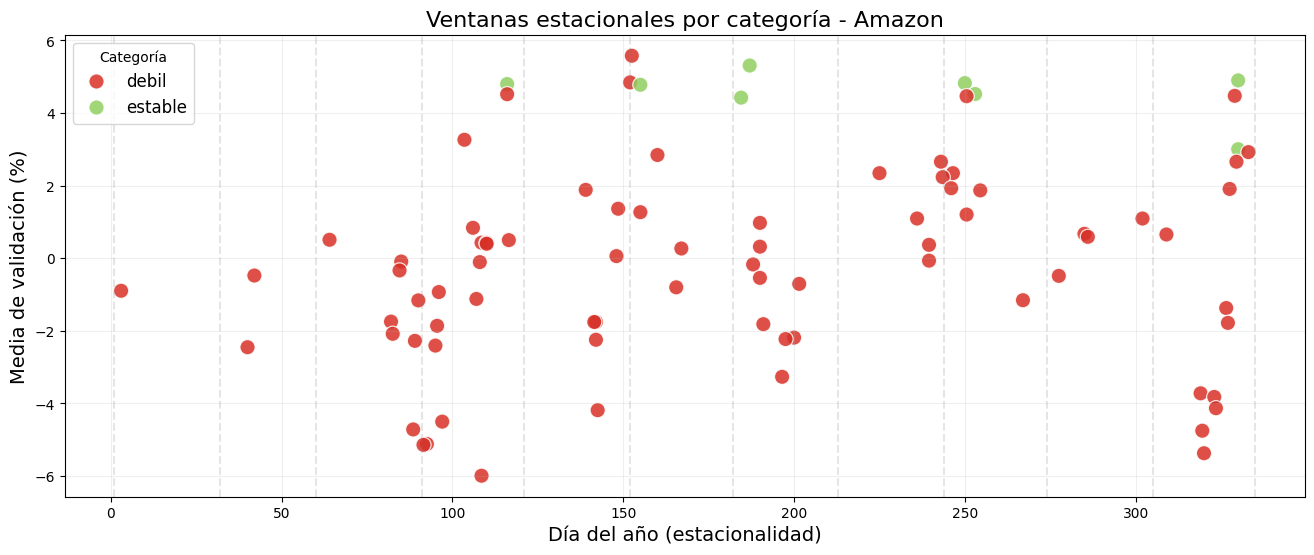

In [51]:
df_clasificado, mejor, estable, estacional = analizar_ventanas(df_scatter)

grafico_estacional(df_clasificado)


In [53]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1) Función robusta para convertir MM-DD → fecha válida
# ---------------------------------------------------------
def convertir_fecha_segura(md):
    mes, dia = map(int, md.split("-"))
    ultimo_dia = calendar.monthrange(2000, mes)[1]
    dia = min(dia, ultimo_dia)  # corrige fechas inválidas
    return datetime(2000, mes, dia)

# ---------------------------------------------------------
# 2) Punto medio de la ventana (para graficar)
# ---------------------------------------------------------
def punto_medio(md_inicio, md_fin):
    f1 = convertir_fecha_segura(md_inicio)
    f2 = convertir_fecha_segura(md_fin)
    medio = f1 + (f2 - f1) / 2
    return medio

# ---------------------------------------------------------
# 3) Gráfico estacional coloreado por categoría
# ---------------------------------------------------------
def grafico_estacional(df):
    df = df.copy()

    # Convertir a fechas reales
    df["fecha_inicio"] = df["md_inicio"].apply(convertir_fecha_segura)
    df["fecha_fin"] = df["md_fin"].apply(convertir_fecha_segura)

    # Punto medio
    df["fecha_medio"] = df.apply(lambda r: punto_medio(r["md_inicio"], r["md_fin"]), axis=1)

    # Mapeo de colores por categoría
    colores = {
        "mejor": "green",
        "estable": "blue",
        "estacional": "orange",
        "debil": "red",
        "otro": "gray"
    }

    df["color"] = df["categoria"].map(colores).fillna("gray")

    # Crear figura
    plt.figure(figsize=(14, 6))

    # Scatter estacional
    plt.scatter(
        df["fecha_medio"],
        df["rend_inicio_a_fin"],
        c=df["color"],
        s=80,
        alpha=0.8,
        edgecolor="black"
    )

    # Eje X con meses en español
    meses_es = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    plt.xticks(
        [datetime(2023, m, 15) for m in range(1, 13)],
        meses_es,
        fontsize=12
    )

    plt.title(f"Gráfico Estacional por Categoría - {name}", fontsize=16)
    plt.xlabel("Mes", fontsize=14)
    plt.ylabel("Rendimiento (%)", fontsize=14)

    # Leyenda manual
    for cat, col in colores.items():
        plt.scatter([], [], c=col, label=cat, s=80, edgecolor="black")

    plt.legend(title="Categoría")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


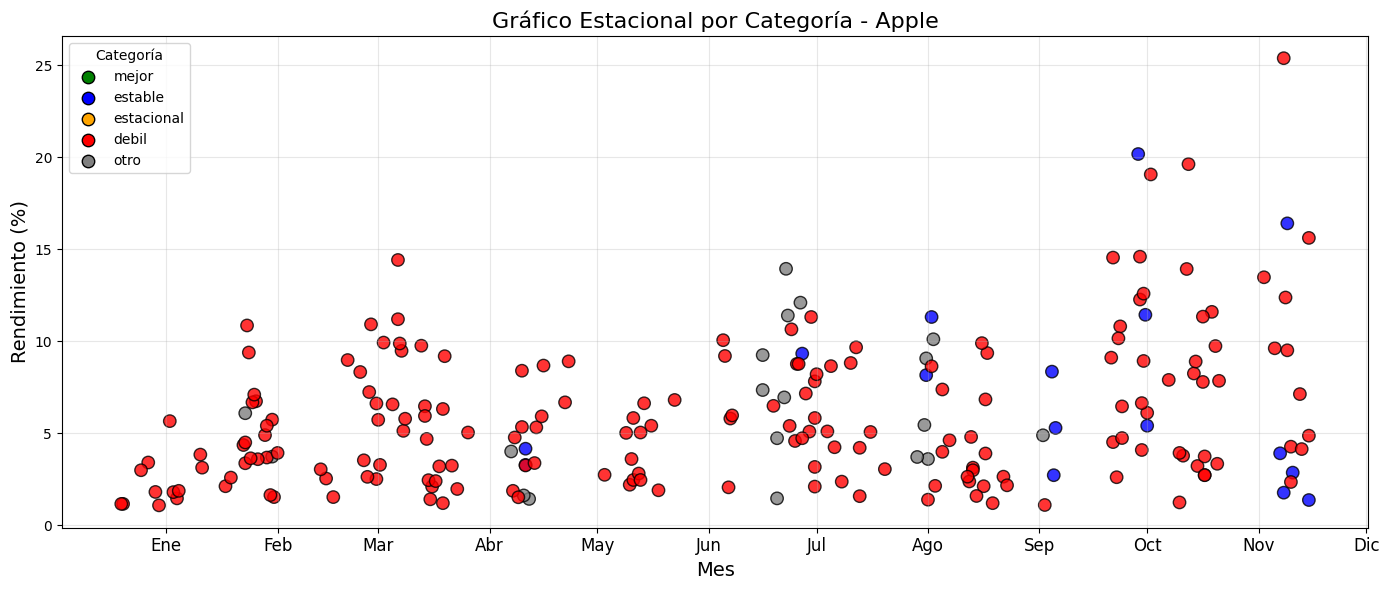

In [27]:
df_clasificado, mejor, estable, estacional = analizar_ventanas(df_scatter)

grafico_estacional(df_clasificado)


In [28]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from datetime import datetime
# import calendar

# ---------------------------------------------------------
# 1. Conversión segura de MM-DD a día del año
# ---------------------------------------------------------
def convertir_a_dia_del_ano(fecha_md):
    if not isinstance(fecha_md, str):
        return np.nan
    try:
        return datetime.strptime("2023-" + fecha_md, "%Y-%m-%d").timetuple().tm_yday
    except:
        return np.nan

# ---------------------------------------------------------
# 2. Obtener mes real (1–12) desde MM-DD
# ---------------------------------------------------------
def obtener_mes(fecha_md):
    if not isinstance(fecha_md, str):
        return np.nan
    try:
        return datetime.strptime("2023-" + fecha_md, "%Y-%m-%d").month
    except:
        return np.nan

# ---------------------------------------------------------
# 3. Clasificación automática según tus criterios
# ---------------------------------------------------------
def clasificar_ventana(row):
    if row["ranking"] <= 10:
        return "MEJOR"
    if row["pct_acierto"] == 100 and row["media_validacion"] > 4:
        return "ESTABLE"
    if row["media_validacion"] > 0:
        return "ESTACIONAL"
    return "DEBIL"

# ---------------------------------------------------------
# 4. Función principal: analiza y clasifica
# ---------------------------------------------------------
def analizar_ventanas(df):
    df = df.copy()

    df["categoria"] = df.apply(clasificar_ventana, axis=1)
    df["dia_inicio"] = df["md_inicio"].apply(convertir_a_dia_del_ano)
    df["dia_fin"] = df["md_fin"].apply(convertir_a_dia_del_ano)
    df["mes"] = df["md_inicio"].apply(obtener_mes)

    return df

# ---------------------------------------------------------
# 5. Gráfico estacional por meses (en español)
# ---------------------------------------------------------
def grafico_estacional(df):
    df = df.copy()

    meses_es = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

    colores = {
        "MEJOR": "gold",
        "ESTABLE": "green",
        "ESTACIONAL": "dodgerblue",
        "DEBIL": "red"
    }

    plt.figure(figsize=(14,6))

    for categoria, datos in df.groupby("categoria"):
        plt.scatter(
            datos["mes"],
            datos["media_validacion"],
            s=80,
            color=colores.get(categoria, "gray"),
            label=categoria,
            alpha=0.8,
            edgecolor="black"
        )

    plt.xticks(range(1,13), meses_es)
    plt.xlabel("Mes del año")
    plt.ylabel("Media de validación (%)")
    plt.title(f"Gráfico estacional por meses y categoría - {name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


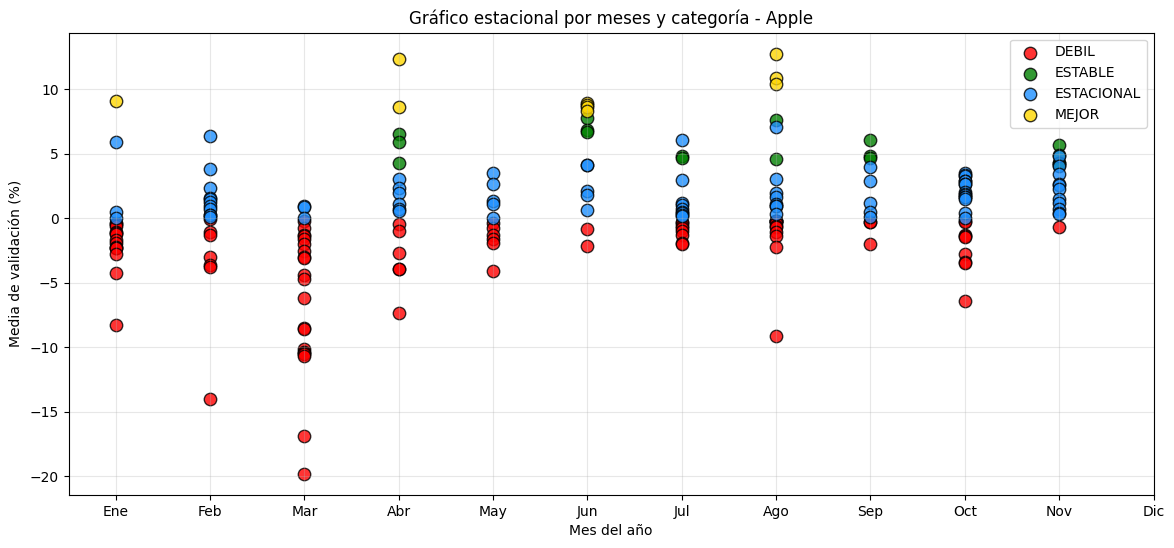

In [29]:
df_clasificado = analizar_ventanas(df_scatter)
grafico_estacional(df_clasificado)


# 6.- Resumen global

In [30]:
df_global = df_total_backtest_ordenado[df_total_backtest_ordenado["periodo"] == "completo"]
df_global.sort_values(by=["retorno_%"],ascending=False)

,capital_inicial,capital_final,beneficio_total,retorno_%,ventanas_operadas,drawdown_max,mejor_operacion,name,periodo
8,10000.0,18305.0,8305.0,83.05,263.0,-167.9,299.5,Nvidia,completo
29,10000.0,18293.6,8293.6,82.94,333.0,-237.4,500.3,Broadcom,completo
17,10000.0,17006.9,7006.9,70.07,344.0,-162.5,194.4,Alphabet Class A,completo
20,10000.0,16930.1,6930.1,69.30,342.0,-162.9,193.2,Alphabet Class C,completo
32,10000.0,15936.5,5936.5,59.36,336.0,-220.4,456.1,Tesla,completo
14,10000.0,13157.8,3157.8,31.58,340.0,-191.6,203.8,Meta,completo
35,10000.0,12376.0,2376.0,23.76,196.0,-84.1,151.2,JPMorgan,completo
47,10000.0,12112.2,2112.2,21.12,335.0,-103.3,140.2,Mastercard,completo
41,10000.0,11826.5,1826.5,18.26,300.0,-134.9,107.5,Visa,completo
74,10000.0,11634.5,1634.5,16.35,190.0,-115.1,159.2,Walmart,completo


In [31]:
df_global = df_global.sort_values("retorno_%")

df_global["color"] = df_global["retorno_%"].apply(
    lambda x: "positivo" if x >= 0 else "negativo"
)


fig = px.bar(
    df_global,
    y="name",
    x="retorno_%",
    orientation="h",
    color="color",
    color_discrete_map={
        "positivo": "green",
        "negativo": "red"
    },
    text="retorno_%",
    title="Rendimiento en los años de test",
    height=700,
    width=1000
)

fig.update_traces(textposition="outside")
fig.update_yaxes(title_text=None)
fig.update_layout(showlegend=False)

# fig.update_traces(
#     texttemplate="<span style='font-size:28px'>%{text}</span>",
#     textposition="outside"
# )


fig.show();


In [32]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df_global)
prof.to_file(output_file='informe_global.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 322.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# PRUEBA GRAFICO ESTACIONAL

In [66]:


# ---------------------------------------------------------
# 1) CLASIFICACIÓN NUEVA
# ---------------------------------------------------------

df = df_scatter.copy()

med_media = df["media_validacion"].median()
med_std   = df["std_validacion"].median()
med_sharpe = df["sharpe"].median()
med_sortino = df["sortino"].median()

def clasificar(fila):
    media = fila["media_validacion"]
    std   = fila["std_validacion"]
    prob  = fila["probabilidad_positivo"]
    sharpe = fila["sharpe"]

    if media >= med_media and std <= med_std and prob >= 0.70 and sharpe >= med_sharpe:
        return "solida"

    if std <= med_std and media >= 0:
        return "estable"

    if media >= med_media and std > med_std:
        return "agresiva"

    if media < med_media and std > med_std:
        return "debil"

    return "neutral"

df["categoria"] = df.apply(clasificar, axis=1)

# ---------------------------------------------------------
# 2) FUNCIONES DE FECHA (sin cambios)
# ---------------------------------------------------------

def convertir_fecha_segura(md):
    mes, dia = map(int, md.split("-"))
    ultimo_dia = calendar.monthrange(2000, mes)[1]
    dia = min(dia, ultimo_dia)
    return datetime(2000, mes, dia)

def punto_medio(md_inicio, md_fin):
    f1 = convertir_fecha_segura(md_inicio)
    f2 = convertir_fecha_segura(md_fin)
    return f1 + (f2 - f1) / 2

# ---------------------------------------------------------
# 3) PREPARAR DATOS PARA EL GRÁFICO
# ---------------------------------------------------------

df["fecha_inicio"] = df["md_inicio"].apply(convertir_fecha_segura)
df["fecha_fin"] = df["md_fin"].apply(convertir_fecha_segura)
df["fecha_medio"] = df.apply(lambda r: punto_medio(r["md_inicio"], r["md_fin"]), axis=1)

# Colores modernos
colores_modernos = {
    "solida": "#4C72B0",
    "estable": "#55A868",
    "agresiva": "#C44E52",
    "debil": "#8172B2",
    "neutral": "#CCB974"
}

# ---------------------------------------------------------
# 4) GRÁFICO ESTACIONAL EN PLOTLY (idéntico al original)
# ---------------------------------------------------------

def grafico_estacional_plotly(df):
    fig = go.Figure()

    # Añadir puntos por categoría (como Matplotlib)
    for categoria, color in colores_modernos.items():
        df_cat = df[df["categoria"] == categoria]

        fig.add_trace(go.Scatter(
            x=df_cat["fecha_medio"],
            y=df_cat["rend_inicio_a_fin"],
            mode="markers",
            name=categoria,
            marker=dict(
                size=10,
                color=color,
                line=dict(width=1, color="black")
            ),
            hovertemplate=(
                "<b>%{text}</b><br>" +
                "Rendimiento: %{y:.2f}%<br>" +
                "Inicio: %{customdata[0]}<br>" +
                "Fin: %{customdata[1]}<br>" +
                "<extra></extra>"
            ),
            text=df_cat["categoria"],
            customdata=np.stack((df_cat["md_inicio"], df_cat["md_fin"]), axis=-1)
        ))

    # Eje X con meses en español
    meses_es = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    fig.update_layout(
        title=f"Gráfico Estacional por Categoría - {name}",
        xaxis=dict(
            tickmode="array",
            tickvals=[datetime(2000, m, 15) for m in range(1, 13)],
            ticktext=meses_es
        ),
        yaxis_title="Rendimiento (%)",
        xaxis_title="Mes",
        template="simple_white",
        legend_title="Categoría",
        # height=500
        height=600,
        width=1000
    )

    fig.show()

# ---------------------------------------------------------
# 5) LLAMADA AL GRÁFICO
# ---------------------------------------------------------

grafico_estacional_plotly(df)
